# 30 — `kde`

`Map.kde` estimates a **continuous density surface** from points by summing a smooth kernel over each one. It
answers "where is this network concentrated?" without imposing a grid, so the result has no cell edges and no
`gridsize` to argue about — the trade is that the smoothing bandwidth is now the thing you have to justify.

By the end you will be able to draw a density surface from a point collection and clip it to a study area.

API: [`Map.kde`](../../reference/static_map.md).

**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")


## The data

The Rhine gauge network, in metres (EPSG:3035) so the kernel is isotropic.

In [2]:
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
print(f"{len(gauges)} gauges, EPSG:{gauges.crs.to_epsg()}")

34 gauges, EPSG:3035


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


## Quickstart — the density surface

`kde` needs only the points. It draws filled density contours — an isochrone-style map where each band encloses
a share of the estimated density.

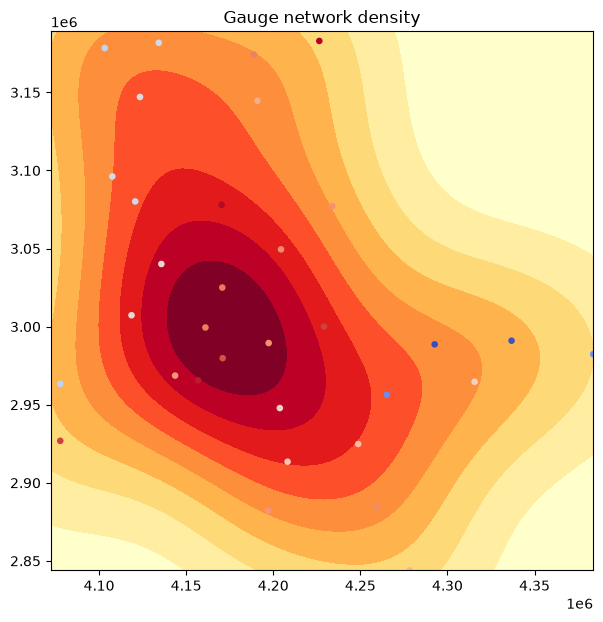

In [3]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.kde(gauges, cmap="YlOrRd")
m.points(gauges, size=14)
m.set_title("Gauge network density")
m.fig;

The peak sits over the middle Rhine, where the gauges bunch. Compare this with the hexbin count map: the same
signal, but the kernel smooths across cell boundaries, so the ridge following the river corridor is continuous
instead of chunky.

Be careful what you claim from it. This is the density of **gauges**, not of water — a KDE of a monitoring
network maps the monitoring, which is a statement about the surveyors, not the river.

## Clipping to a study area

Like `voronoi`, the surface spreads past the data. `clip=` trims it to a boundary so the figure makes a claim
only where the study area is.

| argument | meaning | typical value |
|---|---|---|
| `features` | the point collection to estimate from | a point `FeatureCollection` |
| `clip` | polygons to trim the surface to | a polygon `FeatureCollection` |

In [4]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
germany = states.to_crs(gauges.crs)
print(f"clipping to {len(germany)} states in EPSG:{germany.crs.to_epsg()}")

clipping to 16 states in EPSG:3035


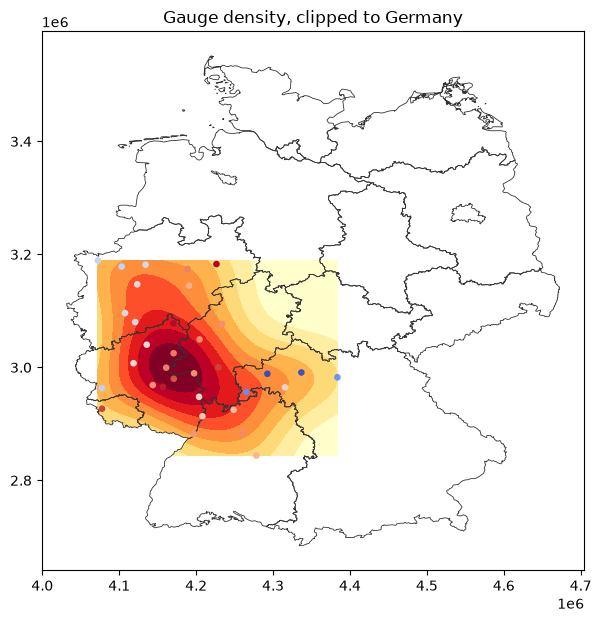

In [5]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 7))
m.kde(gauges, clip=germany, cmap="YlOrRd")
m.polygons(germany, edgecolor="#333333", linewidth=0.6)
m.points(gauges, size=14)
m.set_title("Gauge density, clipped to Germany")
m.fig;

Clipped, the map reads as a national figure: a dense monitoring core along the Rhine and the Ruhr, thinning
sharply to the north and east. The empty states are a real finding — this network does not cover them.

## Takeaway

- `kde(points)` gives a **smooth** density surface — no grid, no cell edges.
- The smoothing is a modelling choice: it invents structure between points, so a KDE on 34 samples is a sketch,
  not a measurement.
- `clip=` keeps the claim inside the study area.
- Reach for `kde` to show *where things concentrate*, and for `hexbin`/`quadtree` when you need per-cell numbers
  a reader can look up.

Next: [`31_cartogram`](31_cartogram.ipynb) distorts polygon geometry by a value instead of colouring it.